# FFT Analysis — Model Error

Analisi spettrale dell'errore (ε = Model − TG obs) con grafici matplotlib.  
I dati vengono caricati tramite `dashboard.data_loader`.

In [7]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Assicura che la root del progetto sia nel path
ROOT = Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dashboard import data_loader

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

print("Modules loaded ✅")
print("Stations:", [s["name"] for s in data_loader.get_stations()])

Modules loaded ✅
Stations: ['Assens', 'Bagenkop', 'Gedser', 'København', 'Køge', 'Sønderborg']


In [8]:
# Stazioni disponibili
import pandas as pd

stations = data_loader.get_stations()
pd.DataFrame(stations)

,id,name,lat,lon
0,28366,Assens,55.270554,9.889665
1,28548,Bagenkop,54.751656,10.672358
2,31616,Gedser,54.572120,11.924483
3,30336,København,55.704292,12.598921
4,30478,Køge,55.455463,12.196472
5,26473,Sønderborg,54.910740,9.785282


In [9]:

# ═══ Parametri ═══
STATION_ID  = "30336"          # København
START       = "2013-01-01"
END         = "2015-12-31"
REMOVE_BIAS = True   # True  → sottrae la media temporale di (Model − TG)
                     #          calcolata sul periodo [START, END]
                     # False → usa ε grezza senza correzione

# Carica i dati tramite data_loader (stessa funzione della dashboard)
df = data_loader.get_station_data(STATION_ID, START, END).copy()
station_name = {s["id"]: s["name"] for s in stations}.get(STATION_ID, STATION_ID)

# ── Bias correction ──────────────────────────────────────────────────────
raw_bias = df["error_m"].mean()
if REMOVE_BIAS:
    df["error_m"] = df["error_m"] - raw_bias
    print(f"[REMOVE_BIAS=True]  bias rimosso: {raw_bias*100:+.3f} cm → ε centrata in 0")
else:
    print(f"[REMOVE_BIAS=False] bias NON rimosso: {raw_bias*100:+.3f} cm")

bias_label = f"(bias corretto: {raw_bias*100:+.3f} cm)" if REMOVE_BIAS else "(bias NON rimosso)"

print(f"Station: {station_name}")
print(f"Rows: {len(df)}")
df.head()


[REMOVE_BIAS=True]  bias rimosso: +3.698 cm → ε centrata in 0
Station: København
Rows: 26076


,valid_time,tg_obs_m,dkss_p82_m,SLP,t2m,u10,v10,station_id,station_name,lat,lon,forcoast_lat,forcoast_lon,forcoast_dist_km,atmo_lat,atmo_lon,atmo_dist_km,error_m,bias_m
0,2013-01-01 01:00:00,0.14,0.193913,99696.2500,280.009949,4.229579,7.465271,30336,København,55.704292,12.598921,55.707,12.603823,0.4301,55.68,12.58,2.95,0.016928,0.083317
1,2013-01-01 02:00:00,0.06,0.158554,99640.6875,279.890564,3.951015,6.850780,30336,København,55.704292,12.598921,55.707,12.603823,0.4301,55.68,12.58,2.95,0.061569,0.083317
2,2013-01-01 03:00:00,-0.06,0.087544,99567.5625,279.877441,4.024655,6.205317,30336,København,55.704292,12.598921,55.707,12.603823,0.4301,55.68,12.58,2.95,0.110559,0.083317
3,2013-01-01 04:00:00,-0.14,0.007175,99461.0000,279.818726,4.074072,5.584961,30336,København,55.704292,12.598921,55.707,12.603823,0.4301,55.68,12.58,2.95,0.110190,0.083317
4,2013-01-01 05:00:00,-0.14,-0.030748,99504.6875,279.999390,4.037759,5.315430,30336,København,55.704292,12.598921,55.707,12.603823,0.4301,55.68,12.58,2.95,0.072267,0.083317


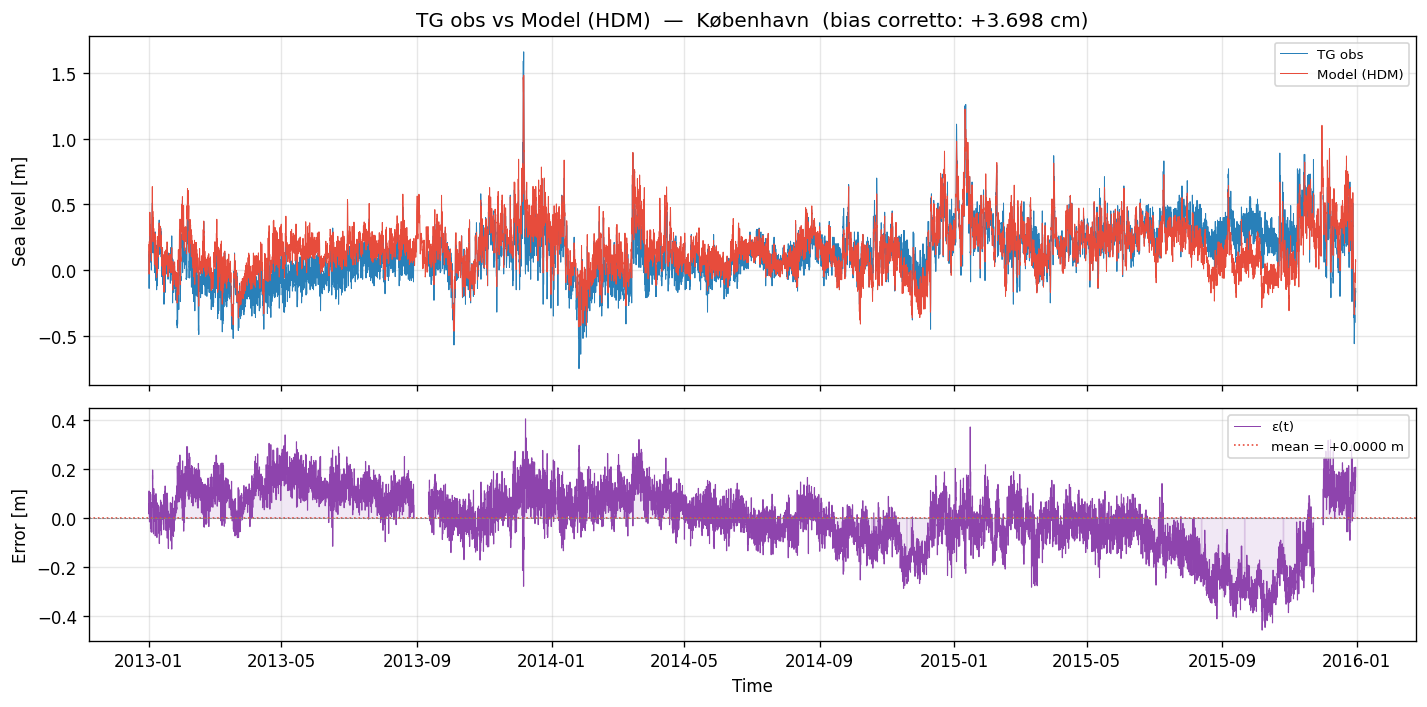

In [10]:

# ═══ Time-series plot (matplotlib) ═══
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                         gridspec_kw={"height_ratios": [3, 2]})

# --- Panel 1: Sea Level ---
ax1 = axes[0]
ax1.plot(df["valid_time"], df["tg_obs_m"],   linewidth=0.6, color="#2980B9", label="TG obs")
ax1.plot(df["valid_time"], df["dkss_p82_m"], linewidth=0.6, color="#E74C3C", label="Model (HDM)")
ax1.set_ylabel("Sea level [m]")
ax1.set_title(f"TG obs vs Model (HDM)  —  {station_name}  {bias_label}", fontsize=12)
ax1.legend(loc="upper right", fontsize=8)

# --- Panel 2: Error ---
ax2 = axes[1]
ax2.plot(df["valid_time"], df["error_m"], linewidth=0.6, color="#8E44AD", label="ε(t)")
ax2.fill_between(df["valid_time"], 0, df["error_m"], color="#8E44AD", alpha=0.12)

mean_err = df["error_m"].mean()
ax2.axhline(mean_err, color="#E74C3C", linestyle=":", linewidth=1, label=f"mean = {mean_err:+.4f} m")
ax2.axhline(0, color="grey", linestyle="--", linewidth=0.5)
ax2.set_ylabel("Error [m]")
ax2.set_xlabel("Time")
ax2.legend(loc="upper right", fontsize=8)

fig.tight_layout()
plt.show()


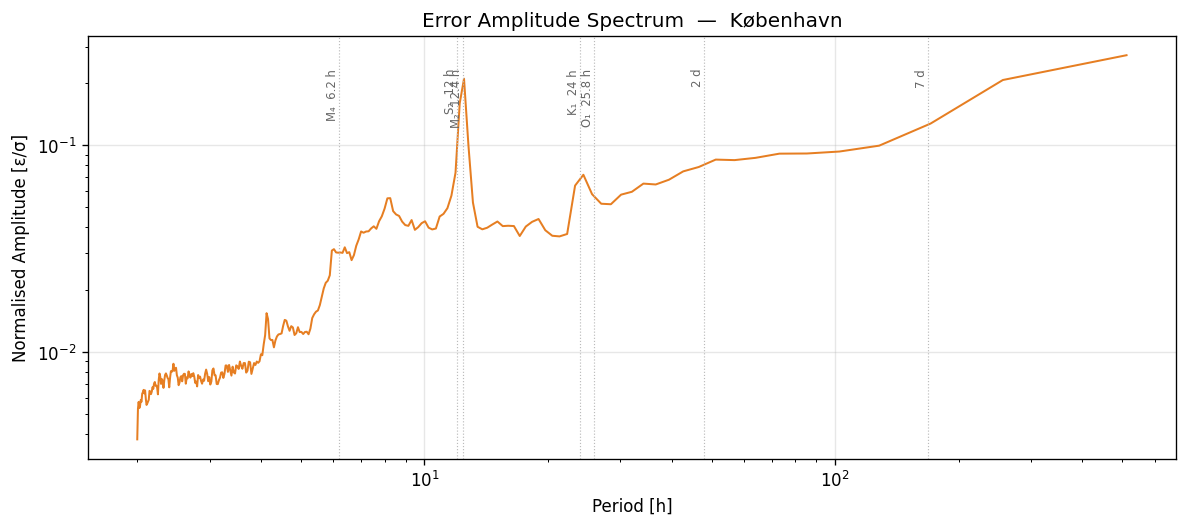

In [11]:

# ═══ PSD / Spettro (matplotlib) ═══
signal = df["error_m"].dropna().values
sigma = np.std(signal) or 1.0
signal_norm = signal / sigma

dt_hours = df["valid_time"].diff().median().total_seconds() / 3600.0
dt_hours = max(dt_hours, 0.5)
fs = 1.0 / dt_hours
nperseg = min(512, len(signal_norm) // 2)

freqs, psd = welch(signal_norm, fs=fs, nperseg=nperseg)
mask = freqs > 0
freqs, psd = freqs[mask], psd[mask]
period_h = 1.0 / freqs

df_freq = freqs[1] - freqs[0] if len(freqs) > 1 else freqs[0]
amplitude = np.sqrt(2.0 * psd * df_freq)

order = np.argsort(period_h)
period_h, amplitude = period_h[order], amplitude[order]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.loglog(period_h, amplitude, linewidth=1.2, color="#E67E22")

ref_lines = [
    ("M₄  6.2 h", 6.21),  ("S₂  12 h", 12.0),
    ("M₂  12.4 h", 12.42), ("K₁  24 h", 23.93),
    ("O₁  25.8 h", 25.82), ("2 d", 48.0),
    ("7 d", 168.0),        ("30 d", 720.0),
]
for label, p_ref in ref_lines:
    if period_h.min() <= p_ref <= period_h.max():
        ax.axvline(p_ref, color="#bbb", linestyle=":", linewidth=0.7)
        ax.text(p_ref, ax.get_ylim()[1] * 0.7, label,
                rotation=90, fontsize=7, color="#666",
                ha="right", va="top")

ax.set_xlabel("Period [h]")
ax.set_ylabel("Normalised Amplitude [ε/σ]")
ax.set_title(f"Error Amplitude Spectrum  —  {station_name}", fontsize=12)

fig.tight_layout()
plt.show()


In [12]:
# ═══ Statistiche errore ═══
from dashboard import figures

stats = figures.compute_stats(df)
for k, v in stats.items():
    print(f"  {k:12s}: {v}")

  total       : 26076
  valid       : 25501
  pct_valid   : 97.8
  bias        : 0.0
  rmse        : 0.12564
  mae         : 0.09837
  std         : 0.12564
